In [2]:
#!/bin/bash
!curl -L -o ./data/fake-vs-real-medicine-datasets-images.zip https://www.kaggle.com/api/v1/datasets/download/surajkumarjha1/fake-vs-real-medicine-datasets-images

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100  266M  100  266M    0     0   251k      0  0:18:05  0:18:05 --:--:--  793k05:53  92400     0  59541      0  1:18:13  0:04:31  1:13:42 4869316.7M    0     0  58221      0  1:20:00  0:05:01  1:14:59 35411:07:46  1:24:20 61900   0     0  54200      0  1:25:56  0:08:08  1:17:48  181k50:58  0:11:43  0:39:15 5041759k      0  0:28:30  0:15:37  0:12:53  693k   0     0   214k      0  0:21:09  0:16:50  0:04:19 1174k


In [3]:
!unzip ./data/fake-vs-real-medicine-datasets-images.zip -d ./data/fake-vs-real-medicine-datasets-images

Archive:  ./data/fake-vs-real-medicine-datasets-images.zip
  inflating: ./data/fake-vs-real-medicine-datasets-images/dataset/Fake/Screenshot 2025-09-17 173830.png  
  inflating: ./data/fake-vs-real-medicine-datasets-images/dataset/Fake/Screenshot 2025-09-17 173925.png  
  inflating: ./data/fake-vs-real-medicine-datasets-images/dataset/Fake/Screenshot 2025-09-17 173947.png  
  inflating: ./data/fake-vs-real-medicine-datasets-images/dataset/Fake/Screenshot 2025-09-17 174004.png  
  inflating: ./data/fake-vs-real-medicine-datasets-images/dataset/Fake/Screenshot 2025-09-17 174048.png  
  inflating: ./data/fake-vs-real-medicine-datasets-images/dataset/Fake/Screenshot 2025-09-17 174103.png  
  inflating: ./data/fake-vs-real-medicine-datasets-images/dataset/Fake/Screenshot 2025-09-17 174126.png  
  inflating: ./data/fake-vs-real-medicine-datasets-images/dataset/Fake/Screenshot 2025-09-17 174153.png  
  inflating: ./data/fake-vs-real-medicine-datasets-images/dataset/Fake/Screenshot 2025-09-17 

In [ ]:
!rm ./data/fake-vs-real-medicine-datasets-images.zip
!rm -rf data/fake-vs-real-medicine-datasets-images/dataset/Fake
!rm -rf data/fake-vs-real-medicine-datasets-images/dataset/Real


In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

# 1. Setup Directories & Hyperparameters
TRAIN_DIR = './data/fake-vs-real-medicine-datasets-images/dataset/train'
VAL_DIR = './data/fake-vs-real-medicine-datasets-images/dataset/val'
TEST_DIR = './data/fake-vs-real-medicine-datasets-images/dataset/test'

BATCH_SIZE = 32
IMG_SIZE = (224, 224) # MobileNetV3 standard input size
EPOCHS = 50
LR = 1e-4

In [17]:
# 2. Load Datasets
print("Loading datasets...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary' # Fake vs Real (0 or 1)
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False # Keep false to align predictions with true labels later
)

class_names = train_ds.class_names
print(f"Class names found: {class_names}")


Loading datasets...
Found 661 files belonging to 2 classes.
Found 453 files belonging to 2 classes.
Found 449 files belonging to 2 classes.
Class names found: ['Fake', 'Real']


E0000 00:00:1779891440.055747  338367 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779891440.056108  351424 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1779891440.074276  338367 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [33]:
# Optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# 3. Build MobileNetV3 Model
# Replace Section 3 in the previous code with this:
print("Building MobileNetV3-Small Model...")
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False 

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# 4. Define Loss, Optimizer, and Metrics
loss_fn = tf.keras.losses.BinaryCrossentropy()
optimizer = tf.keras.optimizers.Adam(learning_rate=LR)

train_loss_metric = tf.keras.metrics.Mean()
train_acc_metric = tf.keras.metrics.BinaryAccuracy()
val_loss_metric = tf.keras.metrics.Mean()
val_acc_metric = tf.keras.metrics.BinaryAccuracy()

# Custom Training Step with tf.function for speed
@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        logits = model(x, training=True)
        loss_value = loss_fn(y, logits)
    grads = tape.gradient(loss_value, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    train_loss_metric.update_state(loss_value)
    train_acc_metric.update_state(y, logits)

@tf.function
def val_step(x, y):
    val_logits = model(x, training=False)
    val_loss_value = loss_fn(y, val_logits)
    val_loss_metric.update_state(val_loss_value)
    val_acc_metric.update_state(y, val_logits)


Building MobileNetV3-Small Model...


In [34]:
# 5. Training Loop with tqdm
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

print("Starting custom training loop...")
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    # Training Progress Bar
    train_pbar = tqdm(train_ds, desc="Training", leave=True)
    for x_batch, y_batch in train_pbar:
        train_step(x_batch, y_batch)
        train_pbar.set_postfix({
            'loss': f"{train_loss_metric.result().numpy():.4f}",
            'acc': f"{train_acc_metric.result().numpy():.4f}"
        })
        
    # Validation Progress Bar
    val_pbar = tqdm(val_ds, desc="Validation", leave=True)
    for x_batch_val, y_batch_val in val_pbar:
        val_step(x_batch_val, y_batch_val)
        val_pbar.set_postfix({
            'val_loss': f"{val_loss_metric.result().numpy():.4f}",
            'val_acc': f"{val_acc_metric.result().numpy():.4f}"
        })

    # Save metrics to history
    history['loss'].append(train_loss_metric.result().numpy())
    history['accuracy'].append(train_acc_metric.result().numpy())
    history['val_loss'].append(val_loss_metric.result().numpy())
    history['val_accuracy'].append(val_acc_metric.result().numpy())

    # Reset metrics for next epoch
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()
    val_loss_metric.reset_state()
    val_acc_metric.reset_state()


Starting custom training loop...

Epoch 1/50


Validation: 100%|██████████| 15/15 [00:04<00:00,  3.32it/s, val_loss=0.6931, val_acc=0.5784]



Epoch 2/50


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.71it/s, val_loss=0.6473, val_acc=0.6269]



Epoch 3/50


...

Validation: 100%|██████████| 15/15 [00:03<00:00,  4.36it/s, val_loss=0.1500, val_acc=0.9757]



Epoch 49/50


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.47it/s, val_loss=0.1444, val_acc=0.9757]



Epoch 50/50


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.50it/s, val_loss=0.1485, val_acc=0.9757]


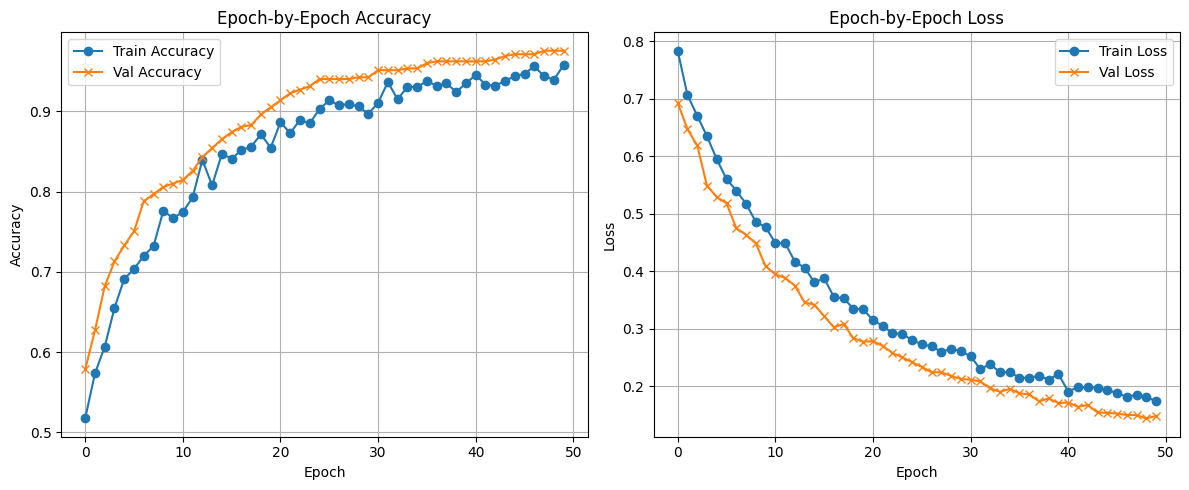

In [35]:
# 6. Plot Accuracy and Loss Curves
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history['val_accuracy'], label='Val Accuracy', marker='x')
plt.title('Epoch-by-Epoch Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='x')
plt.title('Epoch-by-Epoch Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Evaluating model on Test Set...


Testing:   0%|          | 0/15 [00:00<?, ?it/s]W0000 00:00:1779892621.728070  366587 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1779892621.728167  338367 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
Testing: 100%|██████████| 15/15 [00:07<00:00,  1.88it/s]



Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.94      0.97       162
        Real       0.97      0.99      0.98       287

    accuracy                           0.98       449
   macro avg       0.98      0.97      0.97       449
weighted avg       0.98      0.98      0.98       449



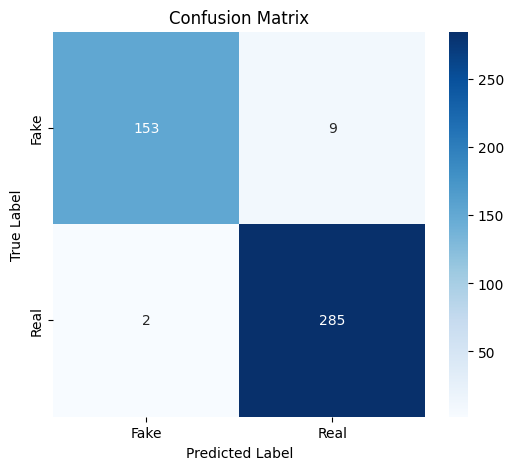

In [36]:
# 7. Evaluate on Test Dataset & Generate Confusion Matrix
print("\nEvaluating model on Test Set...")
true_labels = []
predicted_labels = []

for x_batch_test, y_batch_test in tqdm(test_ds, desc="Testing"):
    preds = model(x_batch_test, training=False)
    preds_binary = (preds.numpy() > 0.5).astype(int)
    
    true_labels.extend(y_batch_test.numpy().flatten())
    predicted_labels.extend(preds_binary.flatten())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Print Classification Report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

# Plot Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [37]:
# Assuming 'model' is your trained MobileNetV3Large model 
# and 'train_ds' is your training dataset generator

def representative_data_gen():
    # Take a small sample (e.g., 100 batches) to calibrate integer ranges
    for x_batch, _ in train_ds.take(100):
        yield [x_batch]

print("\nConverting MobileNetV3Large to INT8 TFLite format...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# Enforce full integer constraints
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model_int8 = converter.convert()

# Save final calibrated model
with open("mobilenetv3_large_int8.tflite", "wb") as f:
    f.write(tflite_model_int8)

print("✓ Success! Saved as mobilenetv3_large_int8.tflite (~4.4 MB)")


Converting MobileNetV3Large to INT8 TFLite format...
INFO:tensorflow:Assets written to: /tmp/tmpy50rnc14/assets


INFO:tensorflow:Assets written to: /tmp/tmpy50rnc14/assets


Saved artifact at '/tmp/tmpy50rnc14'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_951')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  131972555404496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131972555406032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131972555405840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131972555405456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131972555406608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131972555405072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131972555406224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131972555406800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131972555407184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131972555405648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1319725554

/home/gaurav/Programming/sahidawa-india/ml_model_dev_pipeline/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1779892655.729547  338367 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1779892655.729567  338367 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1779892655.729720  338367 reader.cc:83] Reading SavedModel from: /tmp/tmpy50rnc14
I0000 00:00:1779892655.736061  338367 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1779892655.736071  338367 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpy50rnc14
I0000 00:00:1779892655.816662  338367 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1779892656.322749  338367 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpy50rnc14
I0000 00:00:1779892656.446259  338367

✓ Success! Saved as mobilenetv3_large_int8.tflite (~4.4 MB)


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8
W0000 00:00:1779892705.994801  338367 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [38]:
# Save everything (Architecture, Weights, and Optimizer State)
keras_model_path = "mobilenetv3_large_checkpoint.keras"
print(f"Saving full model state for future fine-tuning to {keras_model_path}...")

model.save(keras_model_path)
print("✓ Checkpoint saved successfully!")

Saving full model state for future fine-tuning to mobilenetv3_large_checkpoint.keras...
✓ Checkpoint saved successfully!


In [39]:
!mv mobilenetv3_large_int8.tflite ../apps/ml/models/mobilenetv3_large_int8.tflite 